# 03 - GWAS quality control

Bellenguez et al. (2022) Alzheimer's GWAS, GWAS Catalog **GCST90027158**, GRCh38.

Filters: drop strand-ambiguous (A/T, C/G) variants, keep autosomes, require MAF in [0.01, 0.99],
require a non-empty rsID. The QC'd summary statistics are written straight out in MAGMA's
`SNP CHR BP P N` format - the earlier version of this pipeline also wrote a 229 MB intermediate
copy of the full filtered table, which nothing downstream ever read.

Output: `interim/magma_input.txt`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
from adpipe import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

GWAS = RAW / "GCST90027158_buildGRCh38.tsv.gz"
USECOLS = ["variant_id", "chromosome", "base_pair_location", "p_value",
           "effect_allele", "other_allele", "effect_allele_frequency",
           "n_cases", "n_controls"]
print("reading", GWAS.name, f"({GWAS.stat().st_size / 1e6:.0f} MB gzipped) - takes a few minutes")

reading GCST90027158_buildGRCh38.tsv.gz (755 MB gzipped) - takes a few minutes


In [2]:
gwas = pd.read_csv(GWAS, sep="\t", usecols=USECOLS,
                   dtype={"chromosome": "str", "variant_id": "str",
                          "effect_allele": "str", "other_allele": "str"})
print(f"variants read: {len(gwas):,}")
gwas.head()

variants read: 21,101,114


,variant_id,p_value,chromosome,base_pair_location,effect_allele,other_allele,effect_allele_frequency,n_cases,n_controls
0,rs888953847,0.9626,1,594445,T,C,0.0006,20301,21839
1,rs1040232850,0.2670,1,595762,CTG,C,0.9986,26798,28624
2,rs1390538076,0.8214,1,630947,A,G,0.0003,20301,21839
3,rs1250812823,0.3411,1,646157,A,G,0.0013,20301,21839
4,rs991450070,0.3542,1,726526,C,G,0.0011,20301,21839


In [3]:
steps = [("raw", len(gwas))]

ambiguous = (
    ((gwas["effect_allele"] == "A") & (gwas["other_allele"] == "T"))
    | ((gwas["effect_allele"] == "T") & (gwas["other_allele"] == "A"))
    | ((gwas["effect_allele"] == "C") & (gwas["other_allele"] == "G"))
    | ((gwas["effect_allele"] == "G") & (gwas["other_allele"] == "C"))
)
gwas = gwas[~ambiguous]
steps.append(("strand-unambiguous", len(gwas)))

gwas = gwas[gwas["chromosome"].isin([str(i) for i in range(1, 23)])]
steps.append(("autosomes", len(gwas)))

gwas = gwas[gwas["effect_allele_frequency"].between(0.01, 0.99)]
steps.append(("MAF 1-99%", len(gwas)))

gwas = gwas[gwas["variant_id"].notna() & (gwas["variant_id"].str.strip() != "")]
steps.append(("has rsID", len(gwas)))

gwas = gwas[gwas["p_value"].between(0, 1, inclusive="right")]
steps.append(("valid p-value", len(gwas)))

qc_summary = pd.DataFrame(steps, columns=["step", "n_variants"])
qc_summary["dropped"] = qc_summary["n_variants"].shift().sub(qc_summary["n_variants"]).fillna(0).astype(int)
qc_summary["pct_of_raw"] = (100 * qc_summary["n_variants"] / steps[0][1]).round(2)
save_table(qc_summary, "03_gwas_qc_summary", index=False)
qc_summary

  table -> results/tables/03_gwas_qc_summary.tsv  (6 rows x 4 cols, 0 KB)


,step,n_variants,dropped,pct_of_raw
0,raw,21101114,0,100.00
1,strand-unambiguous,18080993,3020121,85.69
2,autosomes,18080993,0,85.69
3,MAF 1-99%,7356093,10724900,34.86
4,has rsID,7356091,2,34.86
5,valid p-value,7356090,1,34.86


genome-wide significant variants (p < 5e-8): 4,683


  figure -> results/figures/03_gwas_qc.png  (94 KB)


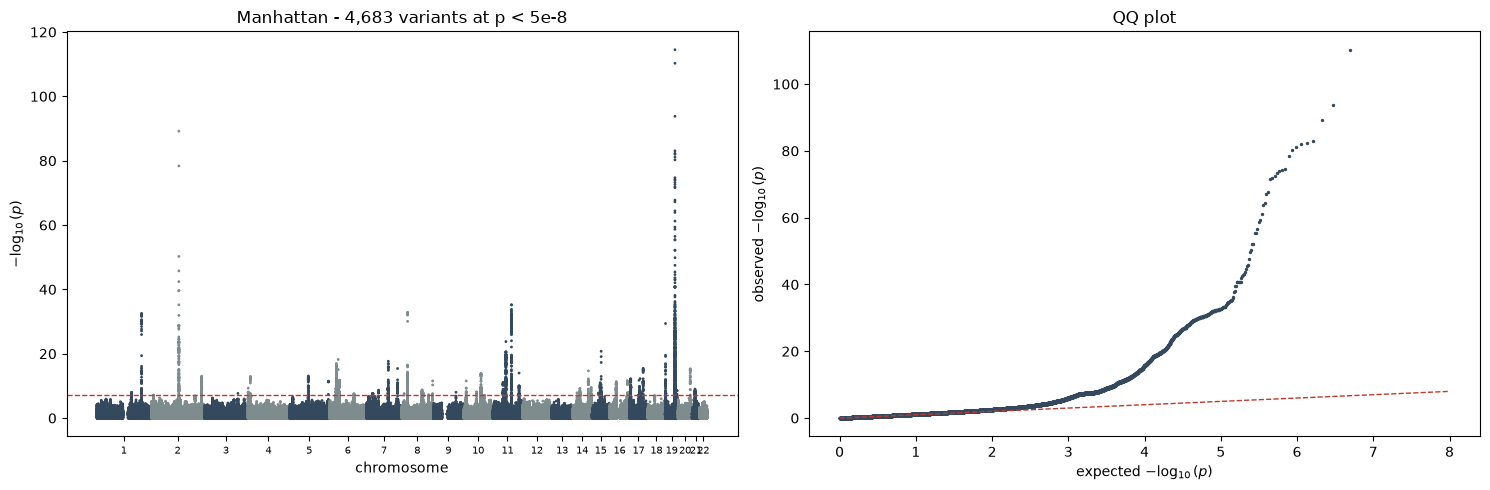

In [4]:
GENOME_WIDE = 5e-8
n_sig = int((gwas["p_value"] < GENOME_WIDE).sum())
print(f"genome-wide significant variants (p < 5e-8): {n_sig:,}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Manhattan - thin to at most 400k points so the figure stays small
chrom = gwas["chromosome"].astype(int).to_numpy()
pos = gwas["base_pair_location"].to_numpy()
nlp = -np.log10(gwas["p_value"].to_numpy())
keep = (nlp > 1) | (np.random.default_rng(0).random(len(nlp)) < 0.02)

order = np.argsort(chrom[keep] * 10**10 + pos[keep])
c, y = chrom[keep][order], nlp[keep][order]
offsets, running = {}, 0.0
x = np.empty(len(c))
for ch in range(1, 23):
    m = c == ch
    if m.sum() == 0:
        continue
    p = pos[keep][order][m]
    x[m] = running + (p - p.min())
    offsets[ch] = running + (p.max() - p.min()) / 2
    running += (p.max() - p.min()) * 1.02

axes[0].scatter(x, y, s=1, c=np.where(c % 2 == 0, "#7f8c8d", "#34495e"), rasterized=True)
axes[0].axhline(-np.log10(GENOME_WIDE), color="#c0392b", ls="--", lw=1)
axes[0].set_xticks(list(offsets.values()))
axes[0].set_xticklabels(list(offsets.keys()), fontsize=7)
axes[0].set(xlabel="chromosome", ylabel=r"$-\log_{10}(p)$",
            title=f"Manhattan - {n_sig:,} variants at p < 5e-8")

# QQ plot on a thinned tail
obs_p = np.sort(gwas["p_value"].to_numpy())
exp_p = (np.arange(1, len(obs_p) + 1) - 0.5) / len(obs_p)
idx = np.unique(np.logspace(0, np.log10(len(obs_p) - 1), 20000).astype(int))
axes[1].scatter(-np.log10(exp_p[idx]), -np.log10(obs_p[idx]), s=2, color="#34495e")
lim = max(-np.log10(exp_p[idx]).max(), 8)
axes[1].plot([0, lim], [0, lim], color="#c0392b", ls="--", lw=1)
axes[1].set(xlabel=r"expected $-\log_{10}(p)$", ylabel=r"observed $-\log_{10}(p)$",
            title="QQ plot")

plt.tight_layout()
save_fig(fig, "03_gwas_qc")
plt.show()

In [5]:
magma_input = gwas[["variant_id", "chromosome", "base_pair_location", "p_value"]].copy()
magma_input["N"] = gwas["n_cases"] + gwas["n_controls"]
magma_input.columns = ["SNP", "CHR", "BP", "P", "N"]

magma_input.to_csv(INTERIM / "magma_input.txt", sep="\t", index=False)
size = (INTERIM / "magma_input.txt").stat().st_size / 1e6
print(f"interim -> interim/magma_input.txt ({len(magma_input):,} variants, {size:.0f} MB)")
magma_input.head()

interim -> interim/magma_input.txt (7,356,090 variants, 275 MB)


,SNP,CHR,BP,P,N
5,rs151190501,1,727233,0.64240,467810
6,rs61769339,1,727242,0.04962,459072
10,rs201221815,1,733014,0.79350,452601
12,rs146067153,1,740738,0.08374,452601
13,rs150820983,1,740747,0.40790,443137
